# Multi-seed significance test: DA methods vs baseline

Loads and shows the results saved by `08_multiseed_significance.py` (`results/significance/`).

- each method is fixed at **the λ selected by val R²** in 07
- outer scaffold 5-fold × **10 seeds** (the seed only changes model init and batch order; the data split is fixed)
- test: seed mean per fold → **paired t-test** against the baseline (n=5), **Holm correction** over 15 comparisons
- reference: Wilcoxon (minimum p=0.0625 at n=5), win rate = fraction of the 50 (fold, seed) pairs with higher R² than the baseline

> To recompute the results, set `RERUN = True` below and run (about 40 min)

In [1]:
import os
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

ROOT = r'..'
SIG_DIR = os.path.join(ROOT, 'results', 'significance')
PROPERTIES = ['clearance', 'half_life', 'fu']
METHODS = ['Baseline', 'MMD', 'CORAL', 'DANN', 'CDAN', 'Importance Weighting']

RERUN = False  # if True, re-run 08_multiseed_significance.py (about 40 min)
if RERUN:
    subprocess.run([sys.executable, os.path.join(ROOT, '01_model', '08_multiseed_significance.py')], check=True)

runs = pd.read_csv(os.path.join(SIG_DIR, 'runs.csv'))
summary = pd.read_csv(os.path.join(SIG_DIR, 'summary.csv'))
print(f"runs: {len(runs)} rows  ({runs['seed'].nunique()} seeds × {runs['fold'].nunique()} folds × "
      f"{runs['property'].nunique()} properties × {runs['method'].nunique()} methods)")

runs: 900 rows  (10 seeds × 5 folds × 3 properties × 6 methods)


## 1. Summary table

Green = higher mean than the baseline / red = lower. If no comparison has `p_holm < 0.05`, there is no significant difference.

In [2]:
cols = ['property', 'method', 'lambda', 'r2_mean', 'r2_seed_sd', 'rho_mean', 'rmse_mean',
        'delta_r2', 'delta_rho', 'p_ttest', 'p_wilcoxon', 'p_holm', 'win_rate']
tbl = summary[cols].copy()
tbl['method'] = pd.Categorical(tbl['method'], METHODS)
tbl = tbl.sort_values(['property', 'method']).reset_index(drop=True)

def color_delta(v):
    if pd.isna(v):
        return ''
    return 'color: #1a7f37' if v > 0 else 'color: #cf222e'

(tbl.style
    .format({'lambda': '{:.2f}', 'r2_mean': '{:.4f}', 'r2_seed_sd': '{:.4f}', 'rho_mean': '{:.4f}',
             'rmse_mean': '{:.4f}', 'delta_r2': '{:+.4f}', 'delta_rho': '{:+.4f}', 'p_ttest': '{:.3f}',
             'p_wilcoxon': '{:.3f}', 'p_holm': '{:.3f}', 'win_rate': '{:.0%}'}, na_rep='–')
    .map(color_delta, subset=['delta_r2', 'delta_rho'])
    .background_gradient(subset=['r2_mean'], cmap='Greens'))

,property,method,lambda,r2_mean,r2_seed_sd,rho_mean,rmse_mean,delta_r2,delta_rho,p_ttest,p_wilcoxon,p_holm,win_rate
0,clearance,Baseline,–,0.0969,0.0139,0.3655,0.9482,–,–,–,–,–,–
1,clearance,MMD,0.10,0.0946,0.0171,0.3629,0.9492,-0.0023,-0.0026,0.719,0.812,1.000,50%
2,clearance,CORAL,0.01,0.0962,0.0146,0.3649,0.9484,-0.0007,-0.0006,0.876,0.812,1.000,52%
3,clearance,DANN,0.01,0.0901,0.0122,0.3607,0.9515,-0.0068,-0.0048,0.434,0.812,1.000,48%
4,clearance,CDAN,0.50,0.1062,0.0127,0.3670,0.9431,+0.0093,+0.0015,0.292,0.312,1.000,64%
5,clearance,Importance Weighting,1.00,0.0984,0.0139,0.3641,0.9473,+0.0015,-0.0014,0.788,1.000,1.000,46%
6,fu,Baseline,–,0.2522,0.0201,0.5835,0.8443,–,–,–,–,–,–
7,fu,MMD,1.00,0.2364,0.0339,0.5748,0.8536,-0.0158,-0.0088,0.082,0.125,1.000,40%
8,fu,CORAL,0.30,0.2508,0.0262,0.5828,0.8486,-0.0014,-0.0007,0.950,1.000,1.000,50%
9,fu,DANN,0.10,0.2370,0.0265,0.5790,0.8527,-0.0153,-0.0045,0.100,0.125,1.000,40%


In [3]:
sig = summary[(summary['method'] != 'Baseline') & (summary['p_holm'] < 0.05)]
print('Significant comparisons after Holm correction (p<0.05):', len(sig), 'comparisons')
print('Minimum uncorrected p (paired t):', round(summary['p_ttest'].min(), 4))

Significant comparisons after Holm correction (p<0.05): 0 comparisons
Minimum uncorrected p (paired t): 0.0816


## 2. ΔR² over the baseline (95% CI)

t-distribution confidence intervals from the per-fold seed-mean differences (n=5). If the interval contains 0, the difference cannot be distinguished.

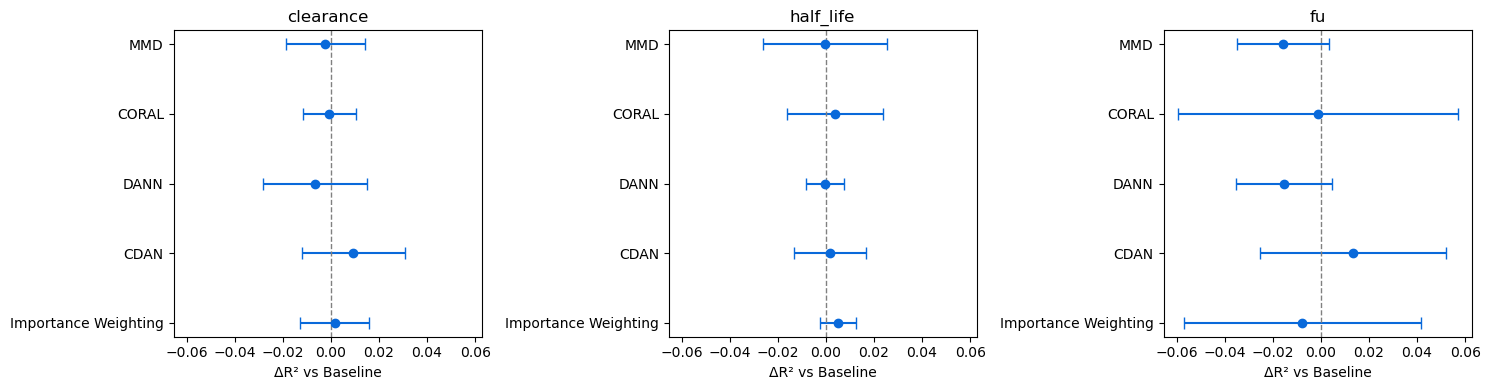

In [4]:
rows = []
for prop in PROPERTIES:
    base = runs[(runs['method'] == 'Baseline') & (runs['property'] == prop)].groupby('fold')['r2'].mean()
    for m in METHODS[1:]:
        d = runs[(runs['method'] == m) & (runs['property'] == prop)].groupby('fold')['r2'].mean() - base
        half = stats.t.ppf(0.975, len(d) - 1) * d.std(ddof=1) / np.sqrt(len(d))
        rows.append({'property': prop, 'method': m, 'delta': d.mean(), 'lo': d.mean() - half, 'hi': d.mean() + half})
ci = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, prop in zip(axes, PROPERTIES):
    c = ci[ci['property'] == prop].reset_index(drop=True)
    ax.errorbar(c['delta'], range(len(c)), xerr=[c['delta'] - c['lo'], c['hi'] - c['delta']],
                fmt='o', color='#0969da', capsize=4)
    ax.axvline(0, color='gray', lw=1, ls='--')
    ax.set_yticks(range(len(c)))
    ax.set_yticklabels(c['method'])
    ax.invert_yaxis()
    ax.set_title(prop)
    ax.set_xlabel('ΔR² vs Baseline')
plt.tight_layout()
plt.show()

## 3. Distribution of 5-fold mean R² per seed

One point = the 5-fold mean of one seed. Check whether the seed-to-seed variation is similar to or larger than the differences between methods.

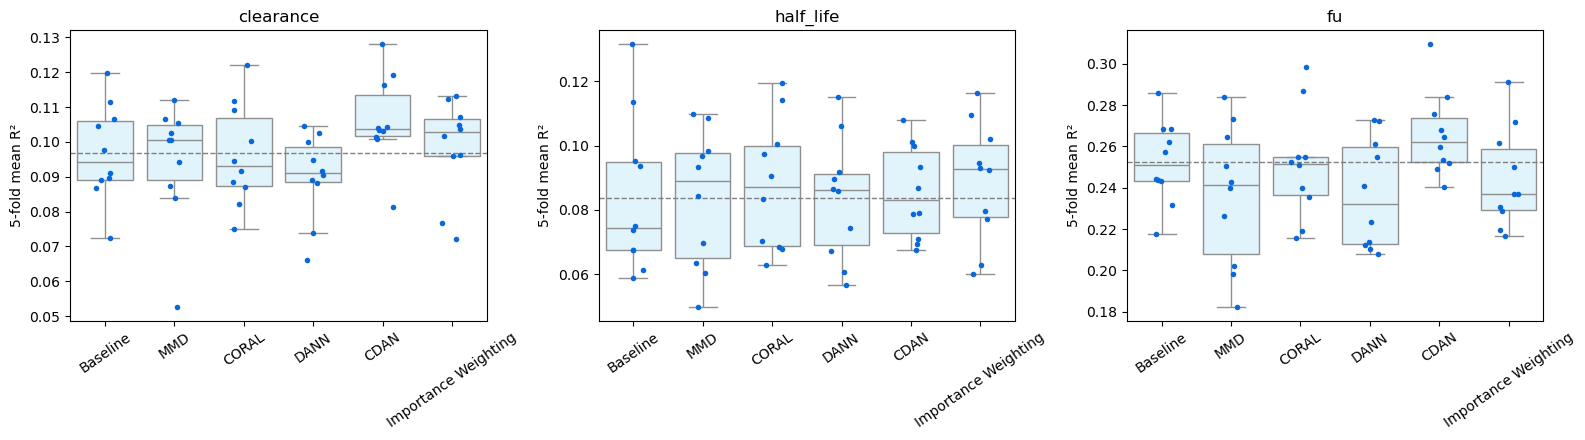

In [5]:
per_seed = runs.groupby(['property', 'method', 'seed'])['r2'].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, prop in zip(axes, PROPERTIES):
    d = per_seed[per_seed['property'] == prop]
    sns.boxplot(data=d, x='method', y='r2', order=METHODS, ax=ax, color='#ddf4ff', fliersize=0)
    sns.stripplot(data=d, x='method', y='r2', order=METHODS, ax=ax, color='#0969da', size=4, jitter=0.15)
    base_mean = d[d['method'] == 'Baseline']['r2'].mean()
    ax.axhline(base_mean, color='gray', lw=1, ls='--')
    ax.set_title(prop)
    ax.set_xlabel('')
    ax.set_ylabel('5-fold mean R²')
    ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

## 4. Per-fold comparison (seed mean)

Check whether the direction relative to the baseline is consistent across folds. If most lines point the same way, the effect is consistent.

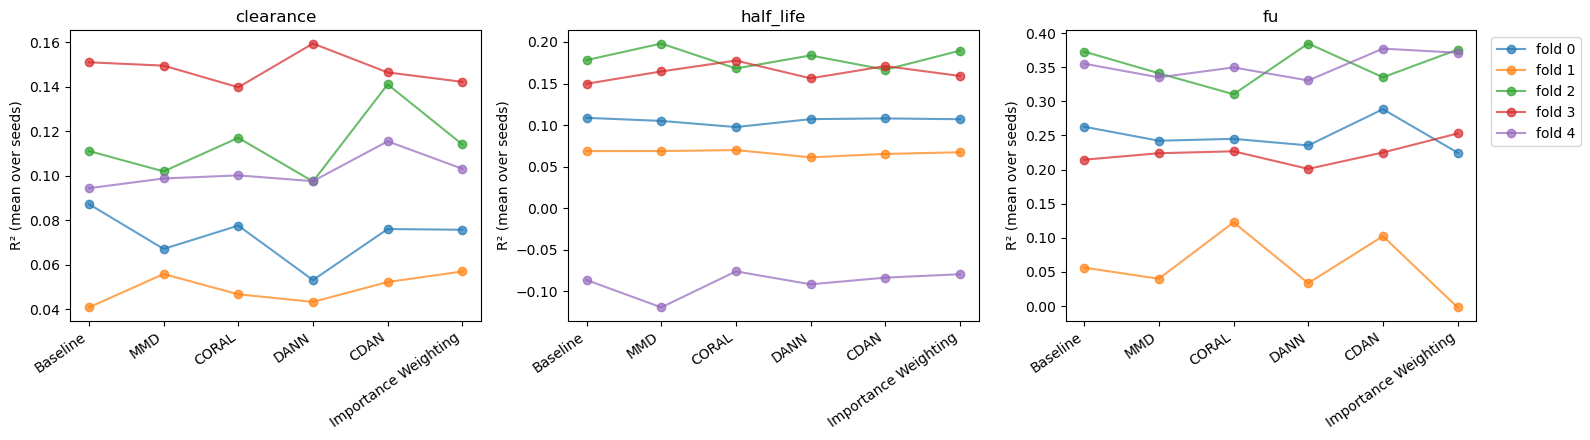

In [6]:
fold_mean = runs.groupby(['property', 'method', 'fold'])['r2'].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, prop in zip(axes, PROPERTIES):
    piv = fold_mean[fold_mean['property'] == prop].pivot(index='fold', columns='method', values='r2')[METHODS]
    for f, row in piv.iterrows():
        ax.plot(range(len(METHODS)), row.values, marker='o', alpha=0.7, label=f'fold {f}')
    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS, rotation=35, ha='right')
    ax.set_title(prop)
    ax.set_ylabel('R² (mean over seeds)')
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Single notebook run vs multi-seed mean

How much the result of 07 (one seed) differs from the multi-seed mean — why a single-run ranking is hard to trust.

In [7]:
import json
best = json.load(open(os.path.join(ROOT, 'results', 'comparison', 'best_performance.json')))
comp = []
for prop in PROPERTIES:
    for m in METHODS:
        if m in best[prop]:
            ms = summary[(summary['property'] == prop) & (summary['method'] == m)]['r2_mean'].iloc[0]
            comp.append({'property': prop, 'method': m, 'single_run_r2 (07)': best[prop][m]['r2_mean'],
                         'multiseed_r2': ms, 'diff': best[prop][m]['r2_mean'] - ms})
comp = pd.DataFrame(comp)
comp.style.format({'single_run_r2 (07)': '{:.4f}', 'multiseed_r2': '{:.4f}', 'diff': '{:+.4f}'})

,property,method,single_run_r2 (07),multiseed_r2,diff
0,clearance,Baseline,0.0891,0.0969,-0.0078
1,clearance,MMD,0.1027,0.0946,+0.0081
2,clearance,CORAL,0.0871,0.0962,-0.0092
3,clearance,DANN,0.0661,0.0901,-0.0240
4,clearance,CDAN,0.1014,0.1062,-0.0049
5,clearance,Importance Weighting,0.0721,0.0984,-0.0263
6,half_life,Baseline,0.1317,0.0838,+0.0479
7,half_life,MMD,0.1086,0.0835,+0.0251
8,half_life,CORAL,0.0684,0.0875,-0.0191
9,half_life,DANN,0.0672,0.0834,-0.0162


## Interpretation

- After Holm correction, **no DA method differs significantly from the baseline** (minimum uncorrected p ≈ 0.08).
- Effect sizes are within roughly ΔR² ±0.015, on the same order as the seed-to-seed variation (r2_seed_sd ≈ 0.01-0.03).
- CDAN is slightly higher on average for all three properties with a 56-64% win rate, but not significantly. MMD and DANN on fu tend to be slightly lower.
- λ was selected on the seed-0 val set, which slightly favours DA, yet there is still no significant difference.
- With only 5 folds the power is low → not "no effect" but "**no evidence that it beats the baseline in this setting**".